# Tarea 3


## Objetivos

a) Entender conceptos y diferencia entre empuje de una aeronave y su potencia.

b) Determinar las curvas características de empuje y potencia disponible y requerido.

c) Encontrar las velocidades que corresponden al mínimo empuje y a la mínima potencia necesaria de una aeronave específica

d) Graficar múltiples datos de medición en un solo diagrama.

## Actividad 1

 A cada condición de vuelo (peso, altura, velocidad, etc.) corresponde un empuje y una potencia para lograr un vuelo recto y nivelado a velocidad constante. Se debe determinar el empuje y la potencia requerida de la aeronave Cessna 172 para todo su rango de velocidad (vel. máxima – vel. Mínima) a una altura constante de H=1000 ft y un peso W=2200lbf. CONSEJO: Para alcanzar la velocidad mínima, es recomendable desactivar el autopiloto de la aeronave y realizar el vuelo de forma manual. El autopiloto mantiene un márgen de seguridad con la velocidad mínima, para no entrar en STALL.

In [ ]:
v_min = 47  * 1.688     #[ft/s]
v_max = 163 * 1.688     #[ft/s]
rho_1000ft = 0.00230839 #[slug/ft3] Digital Dutch
rho_0ft = 0.00237717    #[slug/ft3] Digital Dutch
W = 2200                #[lb]
S_w = 188               #[ft2]
b = 36+1/12             #[ft]
e = 0.75
c_d0 = 0.03             # valor encontrado (0.03)
c_d0_L = -0.07           # valor
T_A_0 = 600             #[lb]

6.9255688534278965


In [157]:
from numpy import pi, linspace

def T_req(v):
    return (.5*rho_1000ft*c_d0*v**2/(W/S_w) + c_d0_L + ((W/S_w)/(.5*rho_1000ft*(v**2)*pi*e*((b**2)/S_w))))*W
print((.5*rho_1000ft*(49**2)*pi*e*((b**2)/S_w)))
print(((W/S_w)/(.5*rho_1000ft*(49**2)*pi*e*(b**2/S_w)))*W)

45.22076823402183
569.3110014812802


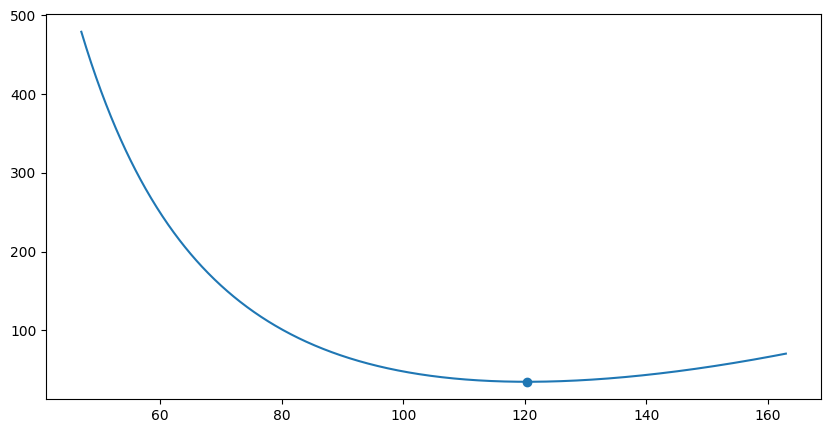

In [158]:
import matplotlib.pyplot as plt

v_linspace = linspace(v_min/1.688, v_max/1.688, 1000)
# print(v_linspace)
v_md = (4/(pi*e*((b**2)/S_w)*c_d0))**.25 * ((W/S_w)/rho_1000ft)**.5

plt.plot(v_linspace, T_req(v_linspace))
plt.scatter([v_md], [T_req(v_md)])

In [159]:
print(T_req(v_min), T_req(v_max))

104.1437588879157 356.8647264436074


## Actividad 2
El motor de una aeronave, en combinación con su hélice, genera una cierta potencia y un empuje disponible. Ambos dependen de la velocidad de avance de la aeronave. Se debe medir la potencia y empuje disponible de la aeronave Cessna 172 en las mismas condiciones de vuelo que en la actividad 1.

Grafique los resultados de todos los valores medidos (potencia requerida, potencia disponible, empuje requerido, empuje disponible) en un solo diagrama sobre la velocidad indicada. Se debe identificar cada uno de los cuatro trazos de forma clara sin utilizar color como medio distintivo. Incluya funciones de aproximación de grado apropiado para cada una de las series. Justifíque la elección del grado de la función de aproximación.

Determine las velocidades que corresponden al mínimo del empuje necesario y al mínimo de la potencia necesaria. Calcule la relación entre ambas velocidades (cociente).

In [160]:
import numpy as np
import matplotlib.pyplot as plt
datos = []
with open('segundo_vuelo.csv', 'r') as archivo:
    next(archivo)                                  # saltar encabezado
    for linea in archivo:
        campos = linea.strip().split(';')
        try:
            fila = [float(c) for c in campos[:30]]  # 30 columnas de datos
        except ValueError:
            continue
        datos.append(fila)

datos = np.array(datos)
print(datos.shape)          # (filas, 30)

v_indicated_2 = datos[:, 0]   # [kt]
v_true_2      = datos[:, 2]   # [kt]
alpha_2       = datos[:, 7]   # [deg]
vpath_2       = datos[:, 10]  # [deg]
altitude_2    = datos[:, 14]  # [ft]
power_av_2    = datos[:, 20]  # [hp]
thrust_av_2   = datos[:, 21]  # [lb]
lift_2        = datos[:, 24]  # [lb]
drag_2        = datos[:, 25]  # [lb]

# print(len(thrust_av), thrust_av[:5])

(450, 30)


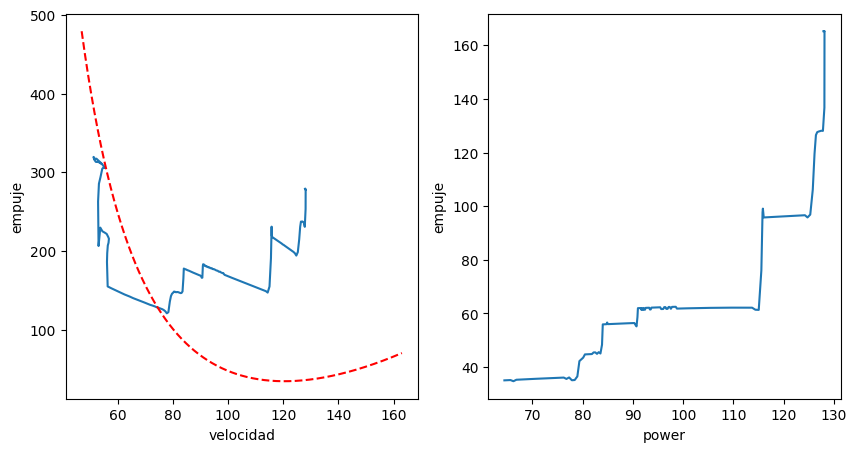

In [161]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_2[150:-10],thrust_av_2[150:-10])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(v_true_2[150:-50],power_av_2[150:-50])
ax2.set_xlabel('power')
ax2.set_ylabel('empuje')
plt.show()

In [162]:

datos = []
with open('primer_vuelo.csv', 'r') as archivo:   # revisa que el nombre coincida con tu archivo
    next(archivo)                                 # saltar encabezado
    for linea in archivo:
        campos = linea.strip().split(';')
        try:
            fila = [float(c) for c in campos[:31]]   # 31 columnas de datos
        except ValueError:
            continue                                  # salta líneas vacías o cortadas
        datos.append(fila)

datos = np.array(datos)

v_indicated_1 = datos[:, 0]    # [kt]  _kias
v_true_1      = datos[:, 2]    # [kt]  _ktas
altitude_1    = datos[:, 21]   # [ft]  MSL
power_av_1    = datos[:, 27]   # [hp]  potencia
thrust_av_1   = datos[:, 28]   # [lb]  empuje

print(len(datos)) 

623


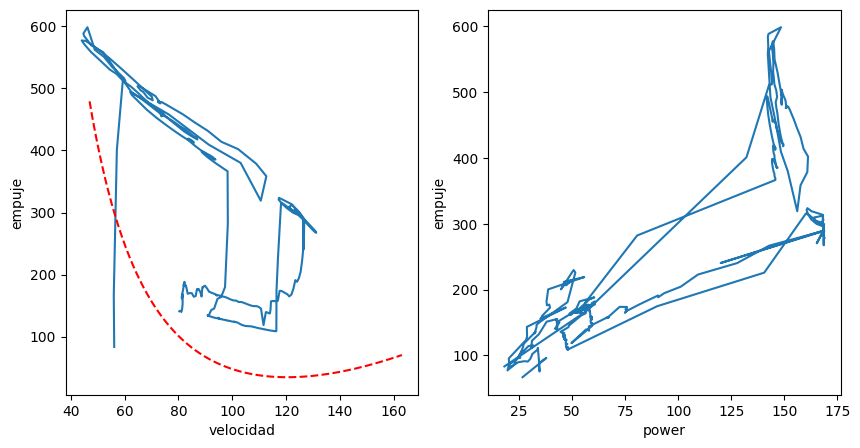

In [163]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_1[0:100 and 500:],thrust_av_1[0:100 and 500:])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(power_av_1,thrust_av_1)
ax2.set_xlabel('power')
ax2.set_ylabel('empuje')
plt.show()

## c_L y c_D para condicion de vuelo

In [164]:
with open('vuelo_cl_cd.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_pol = []    # [kt]  _kias
v_true_pol      = []    # [kt]  _ktas
altitude_pol    = []   # [ft]  MSL
throttle_pol    = []   # [%]  potencia
power_av_pol    = []   # [hp]  potencia
thrust_av_pol   = []   # [lb]  empuje
c_d           = []   # [-]  coeficiente de arrastre
c_l           = []   # [-]  coeficiente de sustentación
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_pol.append(float(i.split(';')[7]))
    v_true_pol.append(float(i.split(';')[9]))
    altitude_pol.append(float(i.split(';')[21]))
    throttle_pol.append(float(i.split(';')[27]))
    power_av_pol.append(float(i.split(';')[29]))
    thrust_av_pol.append(float(i.split(';')[30]))
    c_d.append(float(i.split(';')[39]))
    c_l.append(float(i.split(';')[40]))

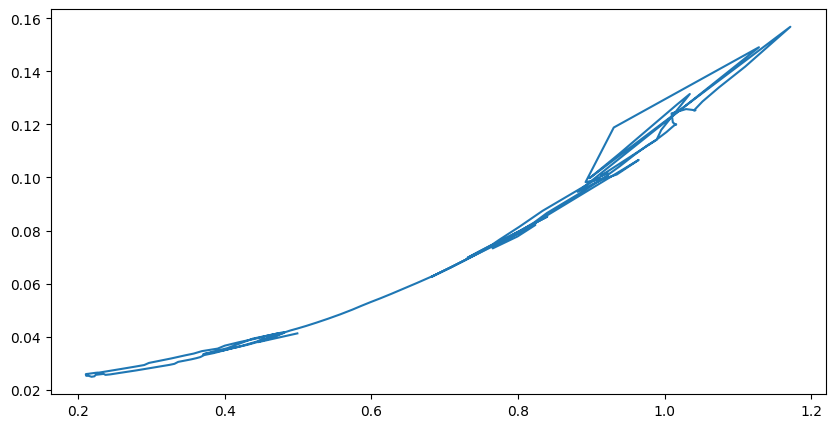

In [165]:
plt.plot(c_d, c_l)

In [166]:
import scipy as sp
with open('vuelo_cl_cd_2.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_pol_2 = []    # [kt]  _kias
v_true_pol_2      = []    # [kt]  _ktas
altitude_pol_2    = []   # [ft]  MSL
throttle_pol_2    = []   # [%]  potencia
power_av_pol_2    = []   # [hp]  potencia
thrust_av_pol_2   = []   # [lb]  empuje
c_d_2           = []   # [-]  coeficiente de arrastre
c_l_2           = []   # [-]  coeficiente de sustentación
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_pol_2.append(float(i.split(';')[7]))
    v_true_pol_2.append(float(i.split(';')[9]))
    altitude_pol_2.append(float(i.split(';')[21]))
    throttle_pol_2.append(float(i.split(';')[27]))
    power_av_pol_2.append(float(i.split(';')[29]))
    thrust_av_pol_2.append(float(i.split(';')[30]))
    c_d_2.append(float(i.split(';')[39]))
    c_l_2.append(float(i.split(';')[40]))

print(c_d_2[43:55], c_l_2[43:55])


[0.25989, 0.25784, 0.22236, 0.21669, 0.20679, 0.19738, 0.18595, 0.17344, 0.15934, 0.03168, 0.00779, -0.02889] [0.02794, 0.02782, 0.0265, 0.02625, 0.02594, 0.02563, 0.02528, 0.02491, 0.02454, 0.02333, 0.0233, 0.02408]


PCHIP:      CD0 = 0.02335 | dCD/dCL(0) = -0.01124
Parabólico: CD0 = 0.02354 | dCD/dCL(0) = -0.01309
k = 0.1206, CL(CDmin) = 0.0543, CDmin = 0.02319


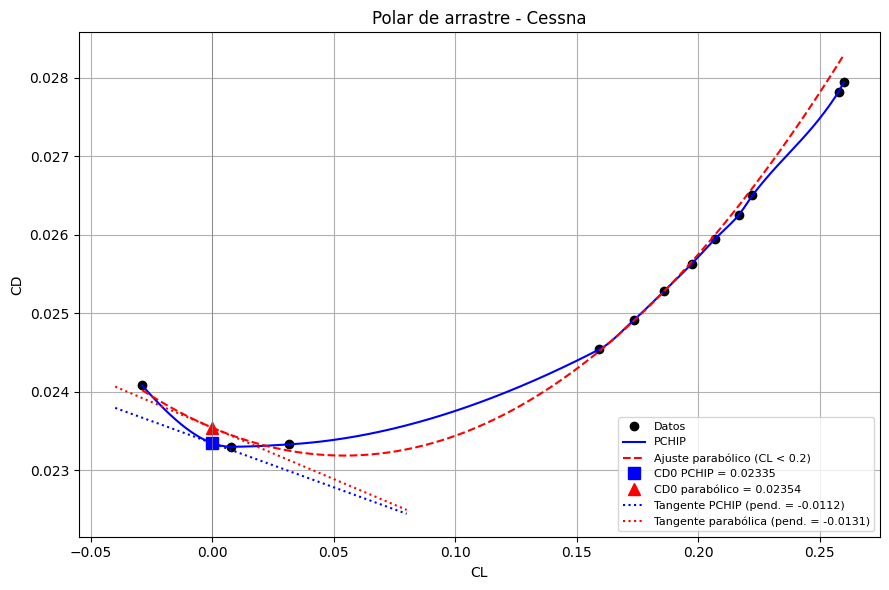

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# ---------------- Datos ----------------
cl = np.array([0.25989, 0.25784, 0.22236, 0.21669, 0.20679, 0.19738,
               0.18595, 0.17344, 0.15934, 0.03168, 0.00779, -0.02889])
cd = np.array([0.02794, 0.02782, 0.0265, 0.02625, 0.02594, 0.02563,
               0.02528, 0.02491, 0.02454, 0.02333, 0.0233, 0.02408])

idx = np.argsort(cl)
cl, cd = cl[idx], cd[idx]

# ---------------- PCHIP ----------------
f = PchipInterpolator(cl, cd)
df = f.derivative()
cd0_pchip = float(f(0.0))
slope_pchip = float(df(0.0))

# ---------------- Ajuste parabólico (CL < 0.2) ----------------
mask = cl < 0.2
q2, q1, q0 = np.polyfit(cl[mask], cd[mask], 2)   # CD = q2*CL^2 + q1*CL + q0
fit = np.poly1d([q2, q1, q0])
cd0_fit, slope_fit = q0, q1
CL0 = -q1 / (2 * q2)
CDmin = q0 - q1**2 / (4 * q2)

print(f"PCHIP:      CD0 = {cd0_pchip:.5f} | dCD/dCL(0) = {slope_pchip:.5f}")
print(f"Parabólico: CD0 = {cd0_fit:.5f} | dCD/dCL(0) = {slope_fit:.5f}")
print(f"k = {q2:.4f}, CL(CDmin) = {CL0:.4f}, CDmin = {CDmin:.5f}")

# ---------------- Gráfica ----------------
cl_new = np.linspace(cl.min(), cl.max(), 400)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(cl, cd, "ko", label="Datos")
ax.plot(cl_new, f(cl_new), "b-", label="PCHIP")
ax.plot(cl_new, fit(cl_new), "r--", label="Ajuste parabólico (CL < 0.2)")

# Punto CD0 y recta tangente en CL = 0
ax.plot(0, cd0_pchip, "bs", ms=8, label=f"CD0 PCHIP = {cd0_pchip:.5f}")
ax.plot(0, cd0_fit, "r^", ms=8, label=f"CD0 parabólico = {cd0_fit:.5f}")
xt = np.linspace(-0.04, 0.08, 20)
ax.plot(xt, cd0_pchip + slope_pchip * xt, "b:", lw=1.5,
        label=f"Tangente PCHIP (pend. = {slope_pchip:.4f})")
ax.plot(xt, cd0_fit + slope_fit * xt, "r:", lw=1.5,
        label=f"Tangente parabólica (pend. = {slope_fit:.4f})")

ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("CL")
ax.set_ylabel("CD")
ax.set_title("Polar de arrastre - Cessna")
ax.grid(True)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("polar_cessna.png", dpi=150)
plt.show()

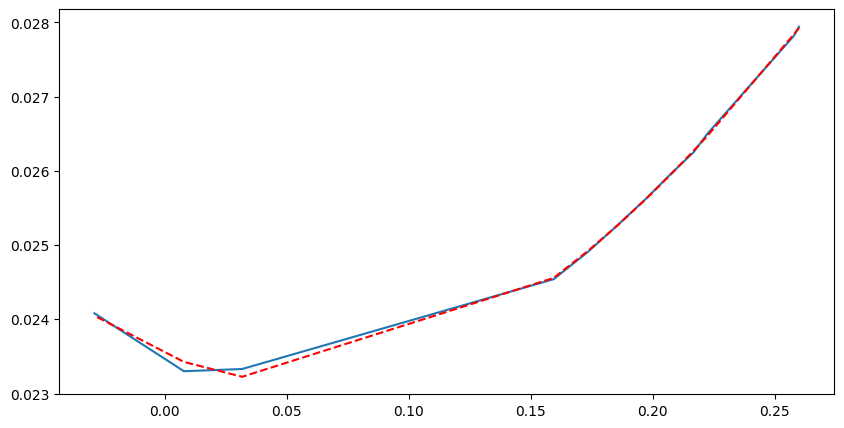

In [168]:
plt.plot(c_d_2[43:55], c_l_2[43:55])
plt.plot(c_d_2[43:55], cubic_fit_fn(c_d_2[43:55]), linestyle='--', color='red')

In [169]:
with open('vuelo_3.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_3 = []    # [kt]  _kias
v_true_3      = []    # [kt]  _ktas
altitude_3    = []   # [ft]  MSL
throttle_3    = []   # [%]  potencia
power_av_3    = []   # [hp]  potencia
thrust_av_3   = []   # [lb]  empuje
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_3.append(float(i.split(';')[7]))
    v_true_3.append(float(i.split(';')[9]))
    altitude_3.append(float(i.split(';')[21]))
    throttle_3.append(float(i.split(';')[27]))
    power_av_3.append(float(i.split(';')[29]))
    thrust_av_3.append(float(i.split(';')[30]))
print(thrust_av_3)


[314.14233, 312.16293, 310.27716, 308.51163, 306.99249, 305.3009, 303.84833, 302.45645, 301.16953, 290.12177, 271.80151, 258.99197, 248.23804, 211.4809, 205.25838, 182.02908, 180.70963, 164.24672, 135.57542, 126.98774, 118.58205, 115.08558, 116.31518, 117.69162, 118.73277, 118.1024, 112.03266, 106.03109, 106.86933, 107.9864, 108.74334, 103.65533, 96.87002, 97.31248, 97.62403, 86.45533, 83.16747, 70.83491, 69.58399, 69.10065, 69.7849, 60.62198, 58.38043, 59.02929, 59.82345, 60.08531, 44.71439, 33.81436, 32.84988, 25.66792, 21.60195, 21.55595, 22.18769, 23.00216, 23.82135, 24.63233, 25.12718, 20.33457, 17.01955, 18.65862, 20.67387, 22.22747, 24.14132, 26.30548, 28.51724, 30.73107, 32.97986, 35.25913, 37.62968, 40.00931, 42.42725, 62.44949, 133.75856, 159.39227, 166.53673, 218.46378, 278.47083, 273.54825, 310.11899, 317.68039, 377.97583, 442.92007, 452.05023, 457.89951, 459.61505, 441.47354, 441.41907, 420.42523, 431.30637, 447.02344, 504.84381, 504.41479]


[ 47.          47.11611612  47.23223223  47.34834835  47.46446446
  47.58058058  47.6966967   47.81281281  47.92892893  48.04504505
  48.16116116  48.27727728  48.39339339  48.50950951  48.62562563
  48.74174174  48.85785786  48.97397397  49.09009009  49.20620621
  49.32232232  49.43843844  49.55455455  49.67067067  49.78678679
  49.9029029   50.01901902  50.13513514  50.25125125  50.36736737
  50.48348348  50.5995996   50.71571572  50.83183183  50.94794795
  51.06406406  51.18018018  51.2962963   51.41241241  51.52852853
  51.64464464  51.76076076  51.87687688  51.99299299  52.10910911
  52.22522523  52.34134134  52.45745746  52.57357357  52.68968969
  52.80580581  52.92192192  53.03803804  53.15415415  53.27027027
  53.38638639  53.5025025   53.61861862  53.73473473  53.85085085
  53.96696697  54.08308308  54.1991992   54.31531532  54.43143143
  54.54754755  54.66366366  54.77977978  54.8958959   55.01201201
  55.12812813  55.24424424  55.36036036  55.47647648  55.59259259
  55.70870

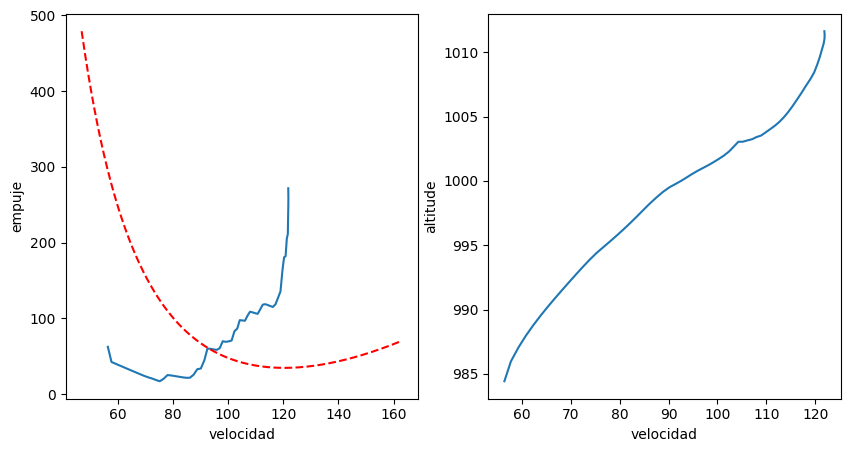

In [170]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_3[10:-20],thrust_av_3[10:-20])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')
print(v_linspace, T_req(v_linspace))
ax2.plot(v_true_3[10:-20],altitude_3[10:-20])
ax2.set_ylabel('altitude')
ax2.set_xlabel('velocidad')
plt.show()

In [171]:
with open('vuelo_4.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_4 = []    # [kt]  _kias
v_true_4      = []    # [kt]  _ktas
altitude_4    = []   # [ft]  MSL
throttle_4    = []   # [%]  potencia
power_av_4    = []   # [hp]  potencia
thrust_av_4   = []   # [lb]  empuje
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_4.append(float(i.split(';')[7]))
    v_true_4.append(float(i.split(';')[9]))
    altitude_4.append(float(i.split(';')[21]))
    throttle_4.append(float(i.split(';')[27]))
    power_av_4.append(float(i.split(';')[29]))
    thrust_av_4.append(float(i.split(';')[30]))

thr_av=max(thrust_av_4[0:40])
loc=thrust_av_4.index(thr_av)
print(loc)
print(thr_av)
pwe_av=power_av_4[loc]
print(pwe_av)

17
406.1958
150.19696


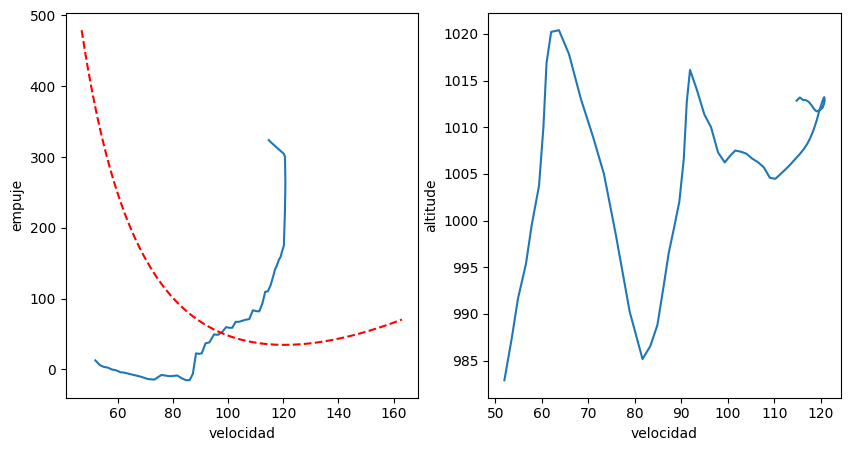

In [172]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_4[65:-15],thrust_av_4[65:-15])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(v_true_4[65:-15],altitude_4[65:-15])
ax2.set_ylabel('altitude')
ax2.set_xlabel('velocidad')
plt.show()

In [173]:
with open('vuelo_5.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_5 = []    # [kt]  _kias
v_true_5      = []    # [kt]  _ktas
altitude_5    = []   # [ft]  MSL
throttle_5    = []   # [%]  potencia
power_av_5    = []   # [hp]  potencia
thrust_av_5   = []   # [lb]  empuje
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_5.append(float(i.split(';')[7]))
    v_true_5.append(float(i.split(';')[9]))
    altitude_5.append(float(i.split(';')[21]))
    throttle_5.append(float(i.split(';')[27]))
    power_av_5.append(float(i.split(';')[29]))
    thrust_av_5.append(float(i.split(';')[30]))


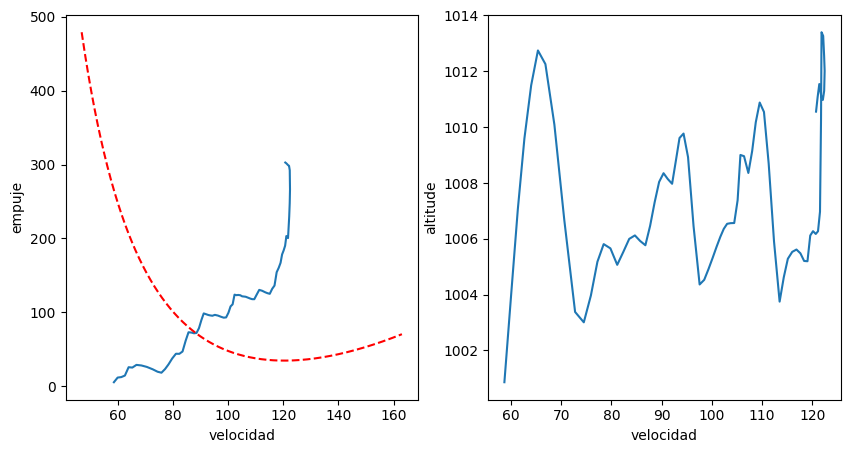

In [174]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_5[68:-30],thrust_av_5[68:-30])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(v_true_5[68:-30],altitude_5[68:-30])
ax2.set_ylabel('altitude')
ax2.set_xlabel('velocidad')
plt.show()